# 2026 South African Local Government Election Analytics

## eThekwini Metropolitan Municipality

This project uses historical Local Government Election data to develop
an evidence-based machine learning solution for selected outcomes of the
4 November 2026 Local Government Election.

Only information publicly available on or before 5 October 2026 is used.

The analysis distinguishes between historical observations, derived
variables and 2026 model estimates.

## 1. Problem Definition

The aim of this project is to analyse historical election results for
eThekwini Metropolitan Municipality and determine whether the available
historical data can support a technically defensible machine learning
solution.

The analysis will examine historical party vote shares, vote totals,
voter turnout and selected ward-level patterns before developing and
evaluating models for 2026 estimates.

## 2. Data Collection

Historical election data was obtained from the Electoral Commission of
South Africa (IEC).

The following Local Government Election datasets are used:

- 2011 Local Government Election
- 2016 Local Government Election
- 2021 Local Government Election

The datasets contain official historical election observations for
eThekwini Metropolitan Municipality.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
with open("ETH (2).csv", "r", encoding="utf-8-sig") as file:
    for i, line in enumerate(file):
        if i < 50:
            print(i, line.strip())

0 ;;;;;;;;;;;;;;;;;;;;;
1 ;;;;;;;;;;;;;;;;;;;;;
2 ;;;;;;;;;;;;;;;;;;;;;
3 ;;;;;;Results Summary - All Ballots;;;;;;;;;;;;;;;
4 ;;;;;;;Printed on: 2011/05/27 11:25:36;;;;;;;;;;;;;;
5 ;;;;;;;;;;;;;;;;;;;;;
6 ;;;;;;Electoral Event:;;;;;Local Government Elections 2011;;;;;;;;;;
7 ;;;;;;Province:;;;;;KwaZulu-Natal;;;;;;;;;;
8 ;;;;;;;;;;;;;;;;;;;;;
9 ;;;;;;Municipality:;;;;;ETH - eThekwini [Durban Metro];;;;;;;;;;
10 ;;;;;;Ward:;;;;;All Wards;;;;;;;;;;
11 ;;;;;;Voting District:;;;;;All Voting Districts;;;;;;;;;;
12 ;;;;;;;;;;;;;;;;;;;;;
13 ;;;;;;;;;;;;;;;;;;;;;
14 ;;;;;;;;;;;;;;;;;;;;;
15 ;Party Name;;;Ward;;;;PR ;;;;"Total
16 (Ward + PR)";;;;DC 40%;;"Total - All Ballots
17 (Ward + PR + DC 40%)";;;
18 ;;;;"Total
19 Valid
20 Votes";"% Total
21 Valid
22 Votes";;;"Total
23 Valid
24 Votes";"% Total
25 Valid
26 Votes";;;"Total
27 Valid
28 Votes";"% Total
29 Valid
30 Votes";;;"Total
31 Valid
32 Votes";"% Total
33 Valid
34 Votes";"Total
35 Valid
36 Votes";"% Total
37 Valid
38 Votes";;
39 ;AFRICAN C

In [3]:
df_2011 = pd.read_csv(
    "ETH (2).csv",
    sep=";",
    encoding="utf-8-sig",
    header=None
)

df_2016 = pd.read_csv(
    "ETH (1).csv",
    sep=";",
    encoding="utf-8-sig",
    header=None
)

df_2021 = pd.read_csv(
    "ETH.csv",
    sep=";",
    encoding="utf-8-sig",
    header=None
)

In [4]:
print("2011:", df_2011.shape)
print("2016:", df_2016.shape)
print("2021:", df_2021.shape)

2011: (40, 22)
2016: (51, 21)
2021: (77, 21)


In [5]:
df_2011.head(20)

,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,Results Summary - All Ballots,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Printed on: 2011/05/27 11:25:36,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,Electoral Event:,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,Province:,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,Municipality:,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
sep=";"

In [7]:
df_2011.head(20)

,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,Results Summary - All Ballots,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Printed on: 2011/05/27 11:25:36,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,Electoral Event:,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,Province:,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,Municipality:,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df_2011.head(25)

,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,Results Summary - All Ballots,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Printed on: 2011/05/27 11:25:36,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,Electoral Event:,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,Province:,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,Municipality:,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df_2016.head(25)

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,Results Summary - All Ballots,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Printed on: 2016/08/11 16:49:53,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,Electoral Event:,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,Province:,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
df_2021.head(25)

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,Results Summary - All Ballots,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Printed on: 2021/11/25 10:21:53,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,Electoral Event:,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,Province:,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
print(df_2011.shape)
print(df_2016.shape)
print(df_2021.shape)

(40, 22)
(51, 21)
(77, 21)


In [12]:
for i, row in df_2011.iterrows():
    if row.astype(str).str.contains("Party Name", case=False, na=False).any():
        print("2011 Party Name row:", i)

2011 Party Name row: 15


In [13]:
for i, row in df_2016.iterrows():
    if row.astype(str).str.contains("Party Name", case=False, na=False).any():
        print("2016 Party Name row:", i)

2016 Party Name row: 16


In [14]:
for i, row in df_2021.iterrows():
    if row.astype(str).str.contains("Party Name", case=False, na=False).any():
        print("2021 Party Name row:", i)

2021 Party Name row: 16


In [15]:
def extract_party_table(df, year):
    # Find the row that contains "Party Name"
    header_row = df[
        df.apply(
            lambda row: row.astype(str)
            .str.contains("Party Name", case=False, na=False)
            .any(),
            axis=1
        )
    ].index[0]

    print(year, "header row:", header_row)

    # Keep everything from the header row downward
    table = df.iloc[header_row:].copy()

    # Reset index
    table = table.reset_index(drop=True)

    return table

In [16]:
table_2011 = extract_party_table(df_2011, 2011)
table_2016 = extract_party_table(df_2016, 2016)
table_2021 = extract_party_table(df_2021, 2021)

2011 header row: 15
2016 header row: 16
2021 header row: 16


In [17]:
table_2011.head(15)

,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
0,NaN,Party Name,NaN,NaN,Ward,NaN,NaN,NaN,PR,NaN,...,Total \n(Ward + PR),NaN,NaN,NaN,DC 40%,NaN,Total - All Ballots\n(Ward + PR + DC 40%),NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,Total \nValid \nVotes,% Total\nValid \nVotes,NaN,NaN,Total \nValid \nVotes,% Total\nValid \nVotes,...,Total \nValid \nVotes,% Total\nValid \nVotes,NaN,NaN,Total \nValid \nVotes,% Total\nValid \nVotes,Total \nValid \nVotes,% Total\nValid \nVotes,NaN,NaN
2,NaN,AFRICAN CHRISTIAN ALLIANCE-AFRIKANER CHRISTEN ...,NaN,NaN,1 158,"0,12%",NaN,NaN,949,0.10 %,...,2 107,"0,11%",NaN,NaN,-,-,2 107,"0,11%",NaN,NaN
3,NaN,AFRICAN CHRISTIAN DEMOCRATIC PARTY,NaN,NaN,7 727,"0,80%",NaN,NaN,"6,555",0.67 %,...,14 282,"0,74%",NaN,NaN,-,-,14 282,"0,74%",NaN,NaN
4,NaN,AFRICAN NATIONAL CONGRESS,NaN,NaN,582 224,"60,11%",NaN,NaN,"603,929",62.02 %,...,1 186 153,"61,07%",NaN,NaN,-,-,1 186 153,"61,07%",NaN,NaN
5,NaN,AFRICAN PEOPLE'S CONVENTION,NaN,NaN,1 914,"0,20%",NaN,NaN,"3,970",0.41 %,...,5 884,"0,30%",NaN,NaN,-,-,5 884,"0,30%",NaN,NaN
6,NaN,AZANIAN PEOPLE'S ORGANISATION,NaN,NaN,1 400,"0,14%",NaN,NaN,"1,238",0.13 %,...,2 638,"0,14%",NaN,NaN,-,-,2 638,"0,14%",NaN,NaN
7,NaN,BLACK CONSCIOUSNESS PARTY,NaN,NaN,245,"0,03%",NaN,NaN,671,0.07 %,...,916,"0,05%",NaN,NaN,-,-,916,"0,05%",NaN,NaN
8,NaN,CONGRESS OF THE PEOPLE,NaN,NaN,3 428,"0,35%",NaN,NaN,"3,882",0.40 %,...,7 310,"0,38%",NaN,NaN,-,-,7 310,"0,38%",NaN,NaN
9,NaN,DEMOCRATIC ALLIANCE/DEMOKRATIESE ALLIANSIE,NaN,NaN,195 770,"20,21%",NaN,NaN,"212,409",21.81 %,...,408 179,"21,02%",NaN,NaN,-,-,408 179,"21,02%",NaN,NaN


In [18]:
table_2016.head(15)

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,NaN,Party Name,NaN,NaN,Ward,NaN,NaN,NaN,PR,NaN,...,Total \n(Ward + PR),NaN,NaN,NaN,DC 40%,NaN,Total - All Ballots\n(Ward + PR + DC 40%),NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,Total \nValid \nVotes,% Total\nValid \nVotes,NaN,NaN,Total \nValid \nVotes,% Total\nValid \nVotes,...,Total \nValid \nVotes,% Total\nValid \nVotes,NaN,NaN,Total \nValid \nVotes,% Total\nValid \nVotes,Total \nValid \nVotes,% Total\nValid \nVotes,NaN,NaN
2,NaN,ACADEMIC CONGRESS UNION,NaN,NaN,439,"0,04%",NaN,NaN,486,"0,04%",...,925,"0,04%",NaN,NaN,-,-,925,"0,04%",NaN,NaN
3,NaN,AFRICAN CHRISTIAN DEMOCRATIC PARTY,NaN,NaN,6 147,"0,55%",NaN,NaN,5 956,"0,54%",...,12 103,"0,54%",NaN,NaN,-,-,12 103,"0,54%",NaN,NaN
4,NaN,AFRICAN INDEPENDENT CONGRESS,NaN,NaN,13 772,"1,23%",NaN,NaN,16 673,"1,51%",...,30 445,"1,37%",NaN,NaN,-,-,30 445,"1,37%",NaN,NaN
5,NaN,AFRICAN MANTUNGWA COMMUNITY,NaN,NaN,1 469,"0,13%",NaN,NaN,1 935,"0,18%",...,3 404,"0,15%",NaN,NaN,-,-,3 404,"0,15%",NaN,NaN
6,NaN,AFRICAN NATIONAL CONGRESS,NaN,NaN,593 621,"52,95%",NaN,NaN,652 891,"59,11%",...,1 246 512,"56,01%",NaN,NaN,-,-,1 246 512,"56,01%",NaN,NaN
7,NaN,AFRICAN PEOPLE'S CONVENTION,NaN,NaN,1 695,"0,15%",NaN,NaN,2 922,"0,26%",...,4 617,"0,21%",NaN,NaN,-,-,4 617,"0,21%",NaN,NaN
8,NaN,AL JAMA-AH,NaN,NaN,2 284,"0,20%",NaN,NaN,2 003,"0,18%",...,4 287,"0,19%",NaN,NaN,-,-,4 287,"0,19%",NaN,NaN
9,NaN,ALLIED MOVEMENT FOR CHANGE,NaN,NaN,1 023,"0,09%",NaN,NaN,860,"0,08%",...,1 883,"0,08%",NaN,NaN,-,-,1 883,"0,08%",NaN,NaN


In [19]:
table_2021.head(15)

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,NaN,Party Name,NaN,NaN,Ward,NaN,NaN,NaN,PR,NaN,...,Total \n(Ward + PR),NaN,NaN,NaN,DC 40%,NaN,Total - All Ballots\n(Ward + PR + DC 40%),NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,Total \nValid \nVotes,% Total\nValid \nVotes,NaN,NaN,Total \nValid \nVotes,% Total\nValid \nVotes,...,Total \nValid \nVotes,% Total\nValid \nVotes,NaN,NaN,Total \nValid \nVotes,% Total\nValid \nVotes,Total \nValid \nVotes,% Total\nValid \nVotes,NaN,NaN
2,NaN,ABANTU BATHO CONGRESS,NaN,NaN,5 866,"0,76%",NaN,NaN,4 998,"0,65%",...,10 864,"0,70%",NaN,NaN,-,-,10 864,"0,70%",NaN,NaN
3,NaN,ACADEMIC CONGRESS UNION,NaN,NaN,289,"0,04%",NaN,NaN,379,"0,05%",...,668,"0,04%",NaN,NaN,-,-,668,"0,04%",NaN,NaN
4,NaN,ACTIONSA,NaN,NaN,11 663,"1,50%",NaN,NaN,18 201,"2,35%",...,29 864,"1,93%",NaN,NaN,-,-,29 864,"1,93%",NaN,NaN
5,NaN,ACTIVE CITIZENS COALITION,NaN,NaN,8 025,"1,03%",NaN,NaN,6 239,"0,81%",...,14 264,"0,92%",NaN,NaN,-,-,14 264,"0,92%",NaN,NaN
6,NaN,ACTIVISTS MOVEMENT OF SOUTH AFRICA,NaN,NaN,917,"0,12%",NaN,NaN,603,"0,08%",...,1 520,"0,10%",NaN,NaN,-,-,1 520,"0,10%",NaN,NaN
7,NaN,ADVANCED DYNAMIC ALLIANCE,NaN,NaN,486,"0,06%",NaN,NaN,481,"0,06%",...,967,"0,06%",NaN,NaN,-,-,967,"0,06%",NaN,NaN
8,NaN,AFRICA RESTORATION ALLIANCE,NaN,NaN,352,"0,05%",NaN,NaN,203,"0,03%",...,555,"0,04%",NaN,NaN,-,-,555,"0,04%",NaN,NaN
9,NaN,AFRICAN BASIC REPUBLICANS,NaN,NaN,0,"0,00%",NaN,NaN,207,"0,03%",...,207,"0,01%",NaN,NaN,-,-,207,"0,01%",NaN,NaN


In [20]:
clean_2011 = table_2011.iloc[2:].copy()

clean_2011 = clean_2011[
    [1, 4, 5, 8, 9, 12, 13]
]

clean_2011.columns = [
    "party",
    "ward_votes",
    "ward_share",
    "pr_votes",
    "pr_share",
    "total_votes",
    "vote_share"
]

clean_2011["year"] = 2011

clean_2011.head()

,party,ward_votes,ward_share,pr_votes,pr_share,total_votes,vote_share,year
2,AFRICAN CHRISTIAN ALLIANCE-AFRIKANER CHRISTEN ...,1 158,"0,12%",949,0.10 %,2 107,"0,11%",2011
3,AFRICAN CHRISTIAN DEMOCRATIC PARTY,7 727,"0,80%","6,555",0.67 %,14 282,"0,74%",2011
4,AFRICAN NATIONAL CONGRESS,582 224,"60,11%","603,929",62.02 %,1 186 153,"61,07%",2011
5,AFRICAN PEOPLE'S CONVENTION,1 914,"0,20%","3,970",0.41 %,5 884,"0,30%",2011
6,AZANIAN PEOPLE'S ORGANISATION,1 400,"0,14%","1,238",0.13 %,2 638,"0,14%",2011


In [21]:
clean_2016 = table_2016.iloc[2:].copy()

clean_2016 = clean_2016[
    [1, 4, 5, 8, 9, 12, 13]
]

clean_2016.columns = [
    "party",
    "ward_votes",
    "ward_share",
    "pr_votes",
    "pr_share",
    "total_votes",
    "vote_share"
]

clean_2016["year"] = 2016

In [22]:
clean_2021 = table_2021.iloc[2:].copy()

clean_2021 = clean_2021[
    [1, 4, 5, 8, 9, 12, 13]
]

clean_2021.columns = [
    "party",
    "ward_votes",
    "ward_share",
    "pr_votes",
    "pr_share",
    "total_votes",
    "vote_share"
]

clean_2021["year"] = 2021

In [23]:
clean_2011.head()

,party,ward_votes,ward_share,pr_votes,pr_share,total_votes,vote_share,year
2,AFRICAN CHRISTIAN ALLIANCE-AFRIKANER CHRISTEN ...,1 158,"0,12%",949,0.10 %,2 107,"0,11%",2011
3,AFRICAN CHRISTIAN DEMOCRATIC PARTY,7 727,"0,80%","6,555",0.67 %,14 282,"0,74%",2011
4,AFRICAN NATIONAL CONGRESS,582 224,"60,11%","603,929",62.02 %,1 186 153,"61,07%",2011
5,AFRICAN PEOPLE'S CONVENTION,1 914,"0,20%","3,970",0.41 %,5 884,"0,30%",2011
6,AZANIAN PEOPLE'S ORGANISATION,1 400,"0,14%","1,238",0.13 %,2 638,"0,14%",2011


In [24]:
clean_2016.head()

,party,ward_votes,ward_share,pr_votes,pr_share,total_votes,vote_share,year
2,ACADEMIC CONGRESS UNION,439,"0,04%",486,"0,04%","0,04%",NaN,2016
3,AFRICAN CHRISTIAN DEMOCRATIC PARTY,6 147,"0,55%",5 956,"0,54%","0,54%",NaN,2016
4,AFRICAN INDEPENDENT CONGRESS,13 772,"1,23%",16 673,"1,51%","1,37%",NaN,2016
5,AFRICAN MANTUNGWA COMMUNITY,1 469,"0,13%",1 935,"0,18%","0,15%",NaN,2016
6,AFRICAN NATIONAL CONGRESS,593 621,"52,95%",652 891,"59,11%","56,01%",NaN,2016


In [25]:
clean_2021.head()

,party,ward_votes,ward_share,pr_votes,pr_share,total_votes,vote_share,year
2,ABANTU BATHO CONGRESS,5 866,"0,76%",4 998,"0,65%","0,70%",NaN,2021
3,ACADEMIC CONGRESS UNION,289,"0,04%",379,"0,05%","0,04%",NaN,2021
4,ACTIONSA,11 663,"1,50%",18 201,"2,35%","1,93%",NaN,2021
5,ACTIVE CITIZENS COALITION,8 025,"1,03%",6 239,"0,81%","0,92%",NaN,2021
6,ACTIVISTS MOVEMENT OF SOUTH AFRICA,917,"0,12%",603,"0,08%","0,10%",NaN,2021


In [26]:
clean_2011 = clean_2011[clean_2011["party"].notna()].copy()
clean_2016 = clean_2016[clean_2016["party"].notna()].copy()
clean_2021 = clean_2021[clean_2021["party"].notna()].copy()

In [27]:
def remove_report_rows(df):
    bad_text = [
        "TOTAL VALID VOTES",
        "TOTAL VOTES",
        "SPOILT",
        "REJECTED"
    ]

    pattern = "|".join(bad_text)

    return df[
        ~df["party"]
        .astype(str)
        .str.upper()
        .str.contains(pattern, na=False)
    ].copy()

In [28]:
clean_2011 = remove_report_rows(clean_2011)
clean_2016 = remove_report_rows(clean_2016)
clean_2021 = remove_report_rows(clean_2021)

In [29]:
for df in [clean_2011, clean_2016, clean_2021]:
    df["party"] = (
        df["party"]
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )

In [30]:
vote_columns = [
    "ward_votes",
    "pr_votes",
    "total_votes"
]

for df in [clean_2011, clean_2016, clean_2021]:
    for col in vote_columns:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(" ", "", regex=False)
            .str.replace(",", "", regex=False)
            .replace("-", np.nan)
        )

        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

In [31]:
share_columns = [
    "ward_share",
    "pr_share",
    "vote_share"
]

for df in [clean_2011, clean_2016, clean_2021]:
    for col in share_columns:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace("%", "", regex=False)
            .str.replace(",", ".", regex=False)
            .str.strip()
            .replace("-", np.nan)
        )

        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

In [32]:
clean_2011.head()

,party,ward_votes,ward_share,pr_votes,pr_share,total_votes,vote_share,year
2,AFRICAN CHRISTIAN ALLIANCE-AFRIKANER CHRISTEN ...,1158.0,0.12,949.0,0.10,2107,0.11,2011
3,AFRICAN CHRISTIAN DEMOCRATIC PARTY,7727.0,0.80,6555.0,0.67,14282,0.74,2011
4,AFRICAN NATIONAL CONGRESS,582224.0,60.11,603929.0,62.02,1186153,61.07,2011
5,AFRICAN PEOPLE'S CONVENTION,1914.0,0.20,3970.0,0.41,5884,0.30,2011
6,AZANIAN PEOPLE'S ORGANISATION,1400.0,0.14,1238.0,0.13,2638,0.14,2011


In [33]:
clean_2016.head()

,party,ward_votes,ward_share,pr_votes,pr_share,total_votes,vote_share,year
2,ACADEMIC CONGRESS UNION,439.0,0.04,486.0,0.04,NaN,NaN,2016
3,AFRICAN CHRISTIAN DEMOCRATIC PARTY,6147.0,0.55,5956.0,0.54,NaN,NaN,2016
4,AFRICAN INDEPENDENT CONGRESS,13772.0,1.23,16673.0,1.51,NaN,NaN,2016
5,AFRICAN MANTUNGWA COMMUNITY,1469.0,0.13,1935.0,0.18,NaN,NaN,2016
6,AFRICAN NATIONAL CONGRESS,593621.0,52.95,652891.0,59.11,NaN,NaN,2016


In [34]:
clean_2021.head()

,party,ward_votes,ward_share,pr_votes,pr_share,total_votes,vote_share,year
2,ABANTU BATHO CONGRESS,5866.0,0.76,4998.0,0.65,NaN,NaN,2021
3,ACADEMIC CONGRESS UNION,289.0,0.04,379.0,0.05,NaN,NaN,2021
4,ACTIONSA,11663.0,1.50,18201.0,2.35,NaN,NaN,2021
5,ACTIVE CITIZENS COALITION,8025.0,1.03,6239.0,0.81,NaN,NaN,2021
6,ACTIVISTS MOVEMENT OF SOUTH AFRICA,917.0,0.12,603.0,0.08,NaN,NaN,2021


In [35]:
clean_2011.dtypes

party              str
ward_votes     float64
ward_share     float64
pr_votes       float64
pr_share       float64
total_votes      int64
vote_share     float64
year             int64
dtype: object

In [36]:
elections = pd.concat(
    [clean_2011, clean_2016, clean_2021],
    ignore_index=True
)

In [37]:
elections.head()

,party,ward_votes,ward_share,pr_votes,pr_share,total_votes,vote_share,year
0,AFRICAN CHRISTIAN ALLIANCE-AFRIKANER CHRISTEN ...,1158.0,0.12,949.0,0.10,2107.0,0.11,2011
1,AFRICAN CHRISTIAN DEMOCRATIC PARTY,7727.0,0.80,6555.0,0.67,14282.0,0.74,2011
2,AFRICAN NATIONAL CONGRESS,582224.0,60.11,603929.0,62.02,1186153.0,61.07,2011
3,AFRICAN PEOPLE'S CONVENTION,1914.0,0.20,3970.0,0.41,5884.0,0.30,2011
4,AZANIAN PEOPLE'S ORGANISATION,1400.0,0.14,1238.0,0.13,2638.0,0.14,2011


In [38]:
print("Combined shape:", elections.shape)

Combined shape: (104, 8)


In [39]:
elections.isnull().sum()

party           0
ward_votes      3
ward_share      3
pr_votes       10
pr_share       10
total_votes    84
vote_share     85
year            0
dtype: int64

In [40]:
elections[elections.isnull().any(axis=1)]

,party,ward_votes,ward_share,pr_votes,pr_share,total_votes,vote_share,year
8,INDEPENDENT,17226.0,1.78,NaN,NaN,17226.0,0.89,2011
17,UNITED RESIDENTS FRONT,142.0,0.01,NaN,NaN,142.0,0.01,2011
19,Total Voter Turnout,NaN,NaN,NaN,NaN,990263.0,NaN,2011
20,ACADEMIC CONGRESS UNION,439.0,0.04,486.0,0.04,NaN,NaN,2016
21,AFRICAN CHRISTIAN DEMOCRATIC PARTY,6147.0,0.55,5956.0,0.54,NaN,NaN,2016
...,...,...,...,...,...,...,...,...
99,UNITED CHRISTIAN DEMOCRATIC PARTY,374.0,0.05,626.0,0.08,NaN,NaN,2021
100,UNITED CULTURAL MOVEMENT,119.0,0.02,294.0,0.04,NaN,NaN,2021
101,UNITED INDEPENDENT MOVEMENT,2919.0,0.38,2895.0,0.37,NaN,NaN,2021
102,VRYHEIDSFRONT PLUS,1954.0,0.25,2021.0,0.26,NaN,NaN,2021


In [41]:
elections[
    ["party", "year", "total_votes", "vote_share"]
].isnull().sum()

party           0
year            0
total_votes    84
vote_share     85
dtype: int64

In [42]:
print("2011")
print(clean_2011[["party", "total_votes", "vote_share"]].isnull().sum())

print("\n2016")
print(clean_2016[["party", "total_votes", "vote_share"]].isnull().sum())

print("\n2021")
print(clean_2021[["party", "total_votes", "vote_share"]].isnull().sum())

2011
party          0
total_votes    0
vote_share     1
dtype: int64

2016
party           0
total_votes    29
vote_share     29
dtype: int64

2021
party           0
total_votes    55
vote_share     55
dtype: int64


In [43]:
clean_2016.head(10)

,party,ward_votes,ward_share,pr_votes,pr_share,total_votes,vote_share,year
2,ACADEMIC CONGRESS UNION,439.0,0.04,486.0,0.04,NaN,NaN,2016
3,AFRICAN CHRISTIAN DEMOCRATIC PARTY,6147.0,0.55,5956.0,0.54,NaN,NaN,2016
4,AFRICAN INDEPENDENT CONGRESS,13772.0,1.23,16673.0,1.51,NaN,NaN,2016
5,AFRICAN MANTUNGWA COMMUNITY,1469.0,0.13,1935.0,0.18,NaN,NaN,2016
6,AFRICAN NATIONAL CONGRESS,593621.0,52.95,652891.0,59.11,NaN,NaN,2016
7,AFRICAN PEOPLE'S CONVENTION,1695.0,0.15,2922.0,0.26,NaN,NaN,2016
8,AL JAMA-AH,2284.0,0.20,2003.0,0.18,NaN,NaN,2016
9,ALLIED MOVEMENT FOR CHANGE,1023.0,0.09,860.0,0.08,NaN,NaN,2016
10,AZANIAN PEOPLE'S ORGANISATION,413.0,0.04,476.0,0.04,NaN,NaN,2016
11,CONGRESS OF THE PEOPLE,709.0,0.06,1566.0,0.14,NaN,NaN,2016


In [44]:
clean_2021.head(10)

,party,ward_votes,ward_share,pr_votes,pr_share,total_votes,vote_share,year
2,ABANTU BATHO CONGRESS,5866.0,0.76,4998.0,0.65,NaN,NaN,2021
3,ACADEMIC CONGRESS UNION,289.0,0.04,379.0,0.05,NaN,NaN,2021
4,ACTIONSA,11663.0,1.50,18201.0,2.35,NaN,NaN,2021
5,ACTIVE CITIZENS COALITION,8025.0,1.03,6239.0,0.81,NaN,NaN,2021
6,ACTIVISTS MOVEMENT OF SOUTH AFRICA,917.0,0.12,603.0,0.08,NaN,NaN,2021
7,ADVANCED DYNAMIC ALLIANCE,486.0,0.06,481.0,0.06,NaN,NaN,2021
8,AFRICA RESTORATION ALLIANCE,352.0,0.05,203.0,0.03,NaN,NaN,2021
9,AFRICAN BASIC REPUBLICANS,0.0,0.00,207.0,0.03,NaN,NaN,2021
10,AFRICAN CHRISTIAN DEMOCRATIC PARTY,6022.0,0.78,5893.0,0.76,NaN,NaN,2021
11,AFRICAN DEMOCRATIC CHANGE,4328.0,0.56,3507.0,0.45,NaN,NaN,2021


In [45]:
for df in [clean_2011, clean_2016, clean_2021]:
    df["total_votes"] = (
        df["ward_votes"].fillna(0) +
        df["pr_votes"].fillna(0)
    )
    

In [46]:
for df in [clean_2011, clean_2016, clean_2021]:
    total = df["total_votes"].sum()

    df["vote_share"] = (
        df["total_votes"] / total
    ) * 100

In [47]:
clean_2016[
    ["party", "ward_votes", "pr_votes", "total_votes", "vote_share"]
].head(10)

,party,ward_votes,pr_votes,total_votes,vote_share
2,ACADEMIC CONGRESS UNION,439.0,486.0,925.0,0.041562
3,AFRICAN CHRISTIAN DEMOCRATIC PARTY,6147.0,5956.0,12103.0,0.543807
4,AFRICAN INDEPENDENT CONGRESS,13772.0,16673.0,30445.0,1.367943
5,AFRICAN MANTUNGWA COMMUNITY,1469.0,1935.0,3404.0,0.152947
6,AFRICAN NATIONAL CONGRESS,593621.0,652891.0,1246512.0,56.007782
7,AFRICAN PEOPLE'S CONVENTION,1695.0,2922.0,4617.0,0.207449
8,AL JAMA-AH,2284.0,2003.0,4287.0,0.192622
9,ALLIED MOVEMENT FOR CHANGE,1023.0,860.0,1883.0,0.084606
10,AZANIAN PEOPLE'S ORGANISATION,413.0,476.0,889.0,0.039944
11,CONGRESS OF THE PEOPLE,709.0,1566.0,2275.0,0.102219


In [48]:
clean_2021[
    ["party", "ward_votes", "pr_votes", "total_votes", "vote_share"]
].head(10)

,party,ward_votes,pr_votes,total_votes,vote_share
2,ABANTU BATHO CONGRESS,5866.0,4998.0,10864.0,0.700564
3,ACADEMIC CONGRESS UNION,289.0,379.0,668.0,0.043076
4,ACTIONSA,11663.0,18201.0,29864.0,1.925777
5,ACTIVE CITIZENS COALITION,8025.0,6239.0,14264.0,0.919812
6,ACTIVISTS MOVEMENT OF SOUTH AFRICA,917.0,603.0,1520.0,0.098017
7,ADVANCED DYNAMIC ALLIANCE,486.0,481.0,967.0,0.062357
8,AFRICA RESTORATION ALLIANCE,352.0,203.0,555.0,0.035789
9,AFRICAN BASIC REPUBLICANS,0.0,207.0,207.0,0.013348
10,AFRICAN CHRISTIAN DEMOCRATIC PARTY,6022.0,5893.0,11915.0,0.768337
11,AFRICAN DEMOCRATIC CHANGE,4328.0,3507.0,7835.0,0.505239


In [49]:
print("2011")
print(clean_2011[["total_votes", "vote_share"]].isnull().sum())

print("\n2016")
print(clean_2016[["total_votes", "vote_share"]].isnull().sum())

print("\n2021")
print(clean_2021[["total_votes", "vote_share"]].isnull().sum())

2011
total_votes    0
vote_share     0
dtype: int64

2016
total_votes    0
vote_share     0
dtype: int64

2021
total_votes    0
vote_share     0
dtype: int64


In [50]:
elections = pd.concat(
    [clean_2011, clean_2016, clean_2021],
    ignore_index=True
)

In [51]:
elections[
    ["party", "year", "total_votes", "vote_share"]
].isnull().sum()

party          0
year           0
total_votes    0
vote_share     0
dtype: int64

In [52]:
print("Duplicates:", elections.duplicated().sum())

Duplicates: 0


## 5. Combined Historical Dataset

The cleaned 2011, 2016 and 2021 IEC election results were combined into
one historical dataset.

Each row represents a party result for a specific election year.

The combined dataset will be used for exploratory analysis, feature
engineering and machine learning.

Missing values are retained where they reflect unavailable historical
fields rather than being automatically removed.

In [53]:
elections.groupby("year")["party"].count()

year
2011    20
2016    29
2021    55
Name: party, dtype: int64

In [54]:
elections[["year", "party", "total_votes", "vote_share"]].head(20)

,year,party,total_votes,vote_share
0,2011,AFRICAN CHRISTIAN ALLIANCE-AFRIKANER CHRISTEN ...,2107.0,0.108481
1,2011,AFRICAN CHRISTIAN DEMOCRATIC PARTY,14282.0,0.735321
2,2011,AFRICAN NATIONAL CONGRESS,1186153.0,61.070103
3,2011,AFRICAN PEOPLE'S CONVENTION,5884.0,0.302943
4,2011,AZANIAN PEOPLE'S ORGANISATION,2638.0,0.135820
5,2011,BLACK CONSCIOUSNESS PARTY,916.0,0.047161
6,2011,CONGRESS OF THE PEOPLE,7310.0,0.376362
7,2011,DEMOCRATIC ALLIANCE/DEMOKRATIESE ALLIANSIE,408179.0,21.015445
8,2011,INDEPENDENT,17226.0,0.886895
9,2011,INKATHA FREEDOM PARTY,80170.0,4.127621


In [55]:
elections.describe()

,ward_votes,ward_share,pr_votes,pr_share,total_votes,vote_share,year
count,101.000000,101.000000,94.000000,94.000000,1.040000e+02,104.000000,104.000000
mean,28372.485149,2.970495,30351.234043,3.191383,5.498689e+04,2.884615,2017.682692
std,95405.511659,9.683414,104375.448833,10.573169,1.934190e+05,9.808084,3.917262
min,0.000000,0.000000,175.000000,0.020000,0.000000e+00,0.000000,2011.000000
25%,413.000000,0.050000,608.750000,0.070000,9.227500e+02,0.048595,2016.000000
50%,1469.000000,0.150000,1562.000000,0.180000,2.815000e+03,0.151554,2021.000000
75%,5866.000000,0.600000,4791.500000,0.530000,1.046575e+04,0.548465,2021.000000
max,593621.000000,60.110000,652891.000000,62.020000,1.246512e+06,61.070103,2021.000000


In [56]:
elections.groupby("year")["party"].count()

year
2011    20
2016    29
2021    55
Name: party, dtype: int64

In [57]:
total_votes_by_year = (
    elections.groupby("year")["total_votes"]
    .sum()
    .reset_index()
)

total_votes_by_year

,year,total_votes
0,2011,1942281.0
1,2016,2225605.0
2,2021,1550751.0


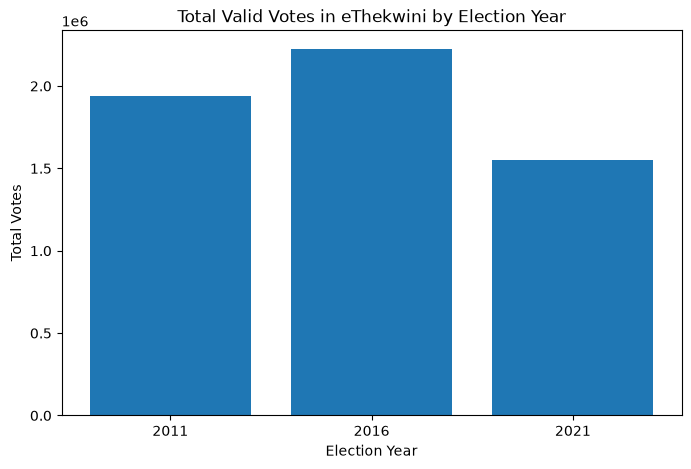

In [58]:
plt.figure(figsize=(8, 5))

plt.bar(
    total_votes_by_year["year"].astype(str),
    total_votes_by_year["total_votes"]
)

plt.title("Total Valid Votes in eThekwini by Election Year")
plt.xlabel("Election Year")
plt.ylabel("Total Votes")

plt.show()


In [59]:
top_parties = (
    elections
    .sort_values(
        ["year", "vote_share"],
        ascending=[True, False]
    )
    .groupby("year")
    .head(10)
)

top_parties[
    ["year", "party", "total_votes", "vote_share"]
]

,year,party,total_votes,vote_share
2,2011,AFRICAN NATIONAL CONGRESS,1186153.0,61.070103
7,2011,DEMOCRATIC ALLIANCE/DEMOKRATIESE ALLIANSIE,408179.0,21.015445
10,2011,MINORITY FRONT,103043.0,5.305257
11,2011,NATIONAL FREEDOM PARTY,91294.0,4.700350
9,2011,INKATHA FREEDOM PARTY,80170.0,4.127621
8,2011,INDEPENDENT,17226.0,0.886895
1,2011,AFRICAN CHRISTIAN DEMOCRATIC PARTY,14282.0,0.735321
14,2011,TRULY ALLIANCE,14020.0,0.721832
6,2011,CONGRESS OF THE PEOPLE,7310.0,0.376362
3,2011,AFRICAN PEOPLE'S CONVENTION,5884.0,0.302943


In [60]:
relevant_parties = (
    elections.groupby("party")["vote_share"]
    .max()
)

relevant_parties = relevant_parties[
    relevant_parties >= 1
].index

eda_parties = elections[
    elections["party"].isin(relevant_parties)
].copy()

### Relevant Party Threshold

For visualisation, parties that received at least 1% of the metro vote
in at least one historical election are included.

This threshold is used only to make graphs easier to interpret.

Smaller parties are not removed from the original historical dataset.

In [61]:
vote_share_table = eda_parties.pivot_table(
    index="year",
    columns="party",
    values="vote_share",
    aggfunc="sum"
)

vote_share_table

party,ACTIONSA,AFRICAN INDEPENDENT CONGRESS,AFRICAN NATIONAL CONGRESS,DEMOCRATIC ALLIANCE,DEMOCRATIC ALLIANCE/DEMOKRATIESE ALLIANSIE,ECONOMIC FREEDOM FIGHTERS,INDEPENDENT,INKATHA FREEDOM PARTY,MINORITY FRONT,NATIONAL FREEDOM PARTY
year,,,,,,,,,,
2011,NaN,NaN,61.070103,NaN,21.015445,NaN,0.886895,4.127621,5.305257,4.700350
2016,NaN,1.367943,56.007782,26.917310,NaN,3.443513,4.198050,4.197241,0.529968,NaN
2021,1.925777,0.666322,42.137261,25.949556,NaN,10.475376,2.127163,7.057677,0.487570,0.340158


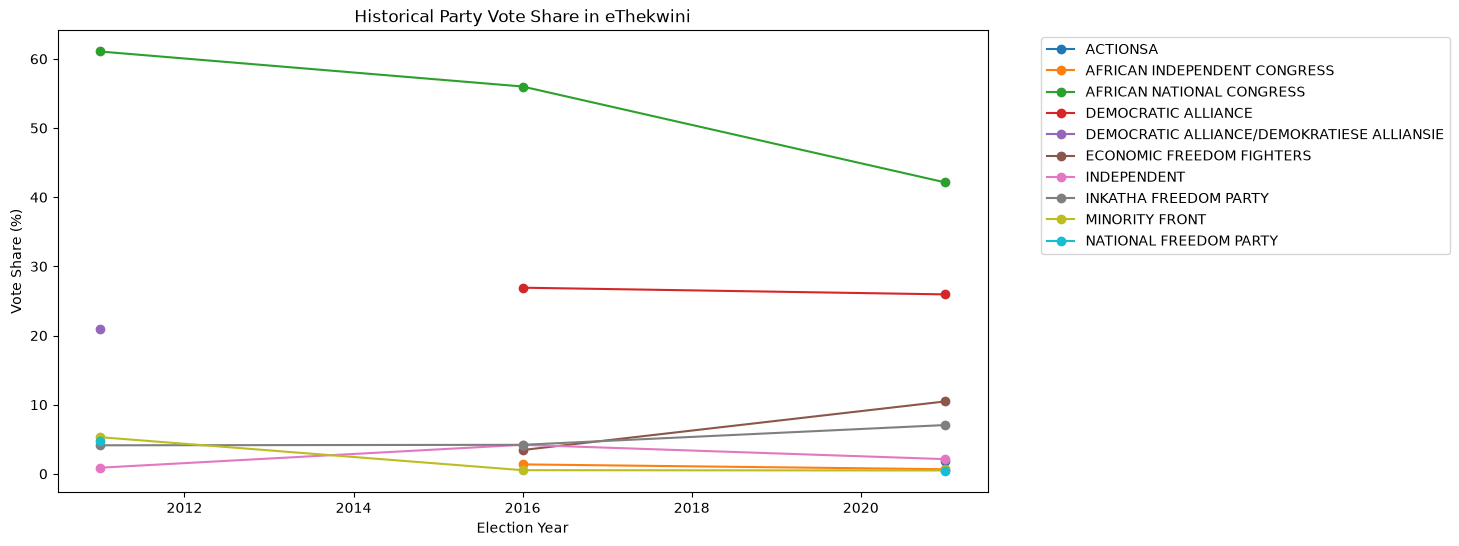

In [62]:
vote_share_table.plot(
    marker="o",
    figsize=(12, 6)
)

plt.title("Historical Party Vote Share in eThekwini")
plt.xlabel("Election Year")
plt.ylabel("Vote Share (%)")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.show()

In [63]:
vote_total_table = eda_parties.pivot_table(
    index="year",
    columns="party",
    values="total_votes",
    aggfunc="sum"
)

vote_total_table

party,ACTIONSA,AFRICAN INDEPENDENT CONGRESS,AFRICAN NATIONAL CONGRESS,DEMOCRATIC ALLIANCE,DEMOCRATIC ALLIANCE/DEMOKRATIESE ALLIANSIE,ECONOMIC FREEDOM FIGHTERS,INDEPENDENT,INKATHA FREEDOM PARTY,MINORITY FRONT,NATIONAL FREEDOM PARTY
year,,,,,,,,,,
2011,NaN,NaN,1186153.0,NaN,408179.0,NaN,17226.0,80170.0,103043.0,91294.0
2016,NaN,30445.0,1246512.0,599073.0,NaN,76639.0,93432.0,93414.0,11795.0,NaN
2021,29864.0,10333.0,653444.0,402413.0,NaN,162447.0,32987.0,109447.0,7561.0,5275.0


In [64]:
eda_parties = eda_parties.sort_values(
    ["party", "year"]
)

eda_parties["vote_share_change"] = (
    eda_parties.groupby("party")["vote_share"]
    .diff()
)

eda_parties[
    [
        "year",
        "party",
        "vote_share",
        "vote_share_change"
    ]
].head(20)

,year,party,vote_share,vote_share_change
51,2021,ACTIONSA,1.925777,NaN
22,2016,AFRICAN INDEPENDENT CONGRESS,1.367943,NaN
61,2021,AFRICAN INDEPENDENT CONGRESS,0.666322,-0.701620
2,2011,AFRICAN NATIONAL CONGRESS,61.070103,NaN
24,2016,AFRICAN NATIONAL CONGRESS,56.007782,-5.062320
63,2021,AFRICAN NATIONAL CONGRESS,42.137261,-13.870521
30,2016,DEMOCRATIC ALLIANCE,26.917310,NaN
74,2021,DEMOCRATIC ALLIANCE,25.949556,-0.967754
7,2011,DEMOCRATIC ALLIANCE/DEMOKRATIESE ALLIANSIE,21.015445,NaN
32,2016,ECONOMIC FREEDOM FIGHTERS,3.443513,NaN


In [65]:
elections = elections.sort_values(
    ["party", "year"]
).reset_index(drop=True)

In [66]:
elections["previous_vote_share"] = (
    elections.groupby("party")["vote_share"]
    .shift(1)
)

In [67]:
elections["previous_total_votes"] = (
    elections.groupby("party")["total_votes"]
    .shift(1)
)

In [68]:
elections["previous_year"] = (
    elections.groupby("party")["year"]
    .shift(1)
)

In [69]:
elections["years_since_previous"] = (
    elections["year"] -
    elections["previous_year"]
)

In [70]:
elections["vote_share_change"] = (
    elections["vote_share"] -
    elections["previous_vote_share"]
)

In [71]:
elections["vote_change"] = (
    elections["total_votes"] -
    elections["previous_total_votes"]
)

In [72]:
elections[
    [
        "year",
        "party",
        "vote_share",
        "previous_vote_share",
        "vote_share_change",
        "total_votes",
        "previous_total_votes",
        "vote_change",
        "years_since_previous"
    ]
].head(25)

,year,party,vote_share,previous_vote_share,vote_share_change,total_votes,previous_total_votes,vote_change,years_since_previous
0,2021,ABANTU BATHO CONGRESS,0.700564,NaN,NaN,10864.0,NaN,NaN,NaN
1,2016,ACADEMIC CONGRESS UNION,0.041562,NaN,NaN,925.0,NaN,NaN,NaN
2,2021,ACADEMIC CONGRESS UNION,0.043076,0.041562,0.001514,668.0,925.0,-257.0,5.0
3,2021,ACTIONSA,1.925777,NaN,NaN,29864.0,NaN,NaN,NaN
4,2021,ACTIVE CITIZENS COALITION,0.919812,NaN,NaN,14264.0,NaN,NaN,NaN
5,2021,ACTIVISTS MOVEMENT OF SOUTH AFRICA,0.098017,NaN,NaN,1520.0,NaN,NaN,NaN
6,2021,ADVANCED DYNAMIC ALLIANCE,0.062357,NaN,NaN,967.0,NaN,NaN,NaN
7,2021,AFRICA RESTORATION ALLIANCE,0.035789,NaN,NaN,555.0,NaN,NaN,NaN
8,2021,AFRICAN BASIC REPUBLICANS,0.013348,NaN,NaN,207.0,NaN,NaN,NaN
9,2011,AFRICAN CHRISTIAN ALLIANCE-AFRIKANER CHRISTEN ...,0.108481,NaN,NaN,2107.0,NaN,NaN,NaN


In [73]:
model_data = elections.dropna(
    subset=[
        "previous_vote_share",
        "previous_total_votes",
        "vote_share",
        "total_votes"
    ]
).copy()

In [74]:
print("Model dataset shape:", model_data.shape)

Model dataset shape: (37, 14)


In [75]:
model_data[
    [
        "year",
        "party",
        "previous_vote_share",
        "previous_total_votes",
        "years_since_previous",
        "vote_share",
        "total_votes"
    ]
].head(20)

,year,party,previous_vote_share,previous_total_votes,years_since_previous,vote_share,total_votes
2,2021,ACADEMIC CONGRESS UNION,0.041562,925.0,5.0,0.043076,668.0
11,2016,AFRICAN CHRISTIAN DEMOCRATIC PARTY,0.735321,14282.0,5.0,0.543807,12103.0
12,2021,AFRICAN CHRISTIAN DEMOCRATIC PARTY,0.543807,12103.0,5.0,0.768337,11915.0
17,2021,AFRICAN INDEPENDENT CONGRESS,1.367943,30445.0,5.0,0.666322,10333.0
19,2021,AFRICAN MANTUNGWA COMMUNITY,0.152947,3404.0,5.0,0.075899,1177.0
21,2016,AFRICAN NATIONAL CONGRESS,61.070103,1186153.0,5.0,56.007782,1246512.0
22,2021,AFRICAN NATIONAL CONGRESS,56.007782,1246512.0,5.0,42.137261,653444.0
25,2016,AFRICAN PEOPLE'S CONVENTION,0.302943,5884.0,5.0,0.207449,4617.0
26,2021,AFRICAN PEOPLE'S CONVENTION,0.207449,4617.0,5.0,0.138965,2155.0
30,2021,AL JAMA-AH,0.192622,4287.0,5.0,0.189972,2946.0


In [76]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [77]:
train = model_data[
    model_data["year"] < 2021
].copy()

test = model_data[
    model_data["year"] == 2021
].copy()

print("Training rows:", train.shape[0])
print("Testing rows:", test.shape[0])

Training rows: 13
Testing rows: 24


In [78]:
features = [
    "previous_vote_share",
    "previous_total_votes",
    "years_since_previous"
]

target = "vote_share"

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

In [79]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (13, 3)
X_test shape: (24, 3)


In [80]:
baseline_predictions = X_test["previous_vote_share"]

In [81]:
baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_predictions
    )
)

baseline_r2 = r2_score(
    y_test,
    baseline_predictions
)

print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)
print("Baseline R²:", baseline_r2)

Baseline MAE: 1.373528390608259
Baseline RMSE: 3.384361188373005
Baseline R²: 0.8782730635313392


## 11. Linear Regression

In [82]:
linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

linear_predictions = linear_model.predict(X_test)

In [83]:
linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print("Linear Regression MAE:", linear_mae)
print("Linear Regression RMSE:", linear_rmse)
print("Linear Regression R²:", linear_r2)

Linear Regression MAE: 1.5296010963811868
Linear Regression RMSE: 3.8229645589576102
Linear Regression R²: 0.8446776960259861


In [84]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=4,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

rf_predictions = rf_model.predict(X_test)

In [85]:
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R²:", rf_r2)

Random Forest MAE: 2.1217670363577965
Random Forest RMSE: 5.5527863775595865
Random Forest R²: 0.6723160182539938


In [86]:
model_results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        baseline_mae,
        linear_mae,
        rf_mae
    ],
    "RMSE": [
        baseline_rmse,
        linear_rmse,
        rf_rmse
    ],
    "R2": [
        baseline_r2,
        linear_r2,
        rf_r2
    ]
})

model_results

,Model,MAE,RMSE,R2
0,Baseline,1.373528,3.384361,0.878273
1,Linear Regression,1.529601,3.822965,0.844678
2,Random Forest,2.121767,5.552786,0.672316


In [87]:
model_results.sort_values(
    "MAE",
    ascending=True
)

,Model,MAE,RMSE,R2
0,Baseline,1.373528,3.384361,0.878273
1,Linear Regression,1.529601,3.822965,0.844678
2,Random Forest,2.121767,5.552786,0.672316


In [88]:
comparison = test[
    ["party", "vote_share"]
].copy()

comparison["baseline_prediction"] = baseline_predictions.values
comparison["linear_prediction"] = linear_predictions
comparison["rf_prediction"] = rf_predictions

comparison

,party,vote_share,baseline_prediction,linear_prediction,rf_prediction
2,ACADEMIC CONGRESS UNION,0.043076,0.041562,-0.039623,0.055208
12,AFRICAN CHRISTIAN DEMOCRATIC PARTY,0.768337,0.543807,0.486265,0.457830
17,AFRICAN INDEPENDENT CONGRESS,0.666322,1.367943,1.349196,2.770686
19,AFRICAN MANTUNGWA COMMUNITY,0.075899,0.152947,0.077006,0.064483
22,AFRICAN NATIONAL CONGRESS,42.137261,56.007782,58.561182,34.201793
26,AFRICAN PEOPLE'S CONVENTION,0.138965,0.207449,0.134073,0.111910
30,AL JAMA-AH,0.189972,0.192622,0.118548,0.111910
32,ALLIED MOVEMENT FOR CHANGE,0.049073,0.084606,0.005448,0.071566
35,AZANIAN PEOPLE'S ORGANISATION,0.035531,0.039944,-0.041317,0.055208
41,CONGRESS OF THE PEOPLE,0.069644,0.102219,0.023890,0.068069


In [89]:
comparison = test[
    ["party", "vote_share"]
].copy()

comparison["baseline_prediction"] = baseline_predictions.values
comparison["linear_prediction"] = linear_predictions
comparison["rf_prediction"] = rf_predictions

comparison

,party,vote_share,baseline_prediction,linear_prediction,rf_prediction
2,ACADEMIC CONGRESS UNION,0.043076,0.041562,-0.039623,0.055208
12,AFRICAN CHRISTIAN DEMOCRATIC PARTY,0.768337,0.543807,0.486265,0.457830
17,AFRICAN INDEPENDENT CONGRESS,0.666322,1.367943,1.349196,2.770686
19,AFRICAN MANTUNGWA COMMUNITY,0.075899,0.152947,0.077006,0.064483
22,AFRICAN NATIONAL CONGRESS,42.137261,56.007782,58.561182,34.201793
26,AFRICAN PEOPLE'S CONVENTION,0.138965,0.207449,0.134073,0.111910
30,AL JAMA-AH,0.189972,0.192622,0.118548,0.111910
32,ALLIED MOVEMENT FOR CHANGE,0.049073,0.084606,0.005448,0.071566
35,AZANIAN PEOPLE'S ORGANISATION,0.035531,0.039944,-0.041317,0.055208
41,CONGRESS OF THE PEOPLE,0.069644,0.102219,0.023890,0.068069


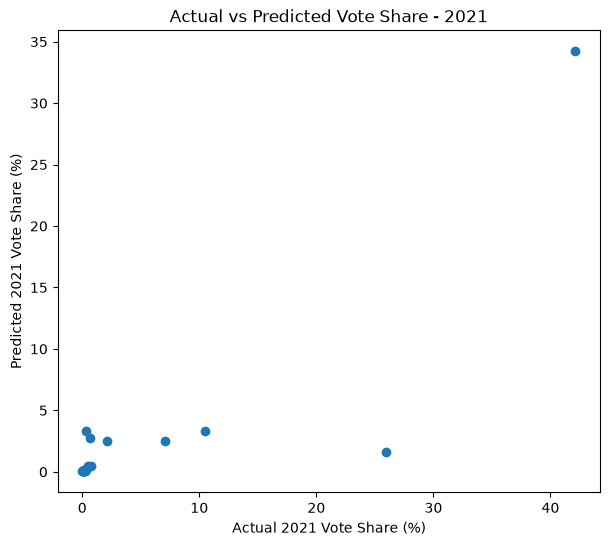

In [90]:
plt.figure(figsize=(7, 6))

plt.scatter(
    comparison["vote_share"],
    comparison["rf_prediction"]
)

plt.xlabel("Actual 2021 Vote Share (%)")
plt.ylabel("Predicted 2021 Vote Share (%)")
plt.title("Actual vs Predicted Vote Share - 2021")

plt.show()

In [91]:
model_results.sort_values("MAE")

,Model,MAE,RMSE,R2
0,Baseline,1.373528,3.384361,0.878273
1,Linear Regression,1.529601,3.822965,0.844678
2,Random Forest,2.121767,5.552786,0.672316


In [92]:
prediction_2026 = elections[
    elections["year"] == 2021
][["party", "vote_share", "total_votes"]].copy()

prediction_2026["estimated_vote_share_2026"] = (
    prediction_2026["vote_share"]
)

prediction_2026.head()

,party,vote_share,total_votes,estimated_vote_share_2026
0,ABANTU BATHO CONGRESS,0.700564,10864.0,0.700564
2,ACADEMIC CONGRESS UNION,0.043076,668.0,0.043076
3,ACTIONSA,1.925777,29864.0,1.925777
4,ACTIVE CITIZENS COALITION,0.919812,14264.0,0.919812
5,ACTIVISTS MOVEMENT OF SOUTH AFRICA,0.098017,1520.0,0.098017


In [93]:
model_error = baseline_mae

prediction_2026["lower_estimate"] = (
    prediction_2026["estimated_vote_share_2026"] - model_error
).clip(lower=0)

prediction_2026["upper_estimate"] = (
    prediction_2026["estimated_vote_share_2026"] + model_error
).clip(upper=100)

In [94]:
metro_forecast = prediction_2026[
    [
        "party",
        "estimated_vote_share_2026",
        "lower_estimate",
        "upper_estimate"
    ]
].sort_values(
    "estimated_vote_share_2026",
    ascending=False
)

metro_forecast.head(15)

,party,estimated_vote_share_2026,lower_estimate,upper_estimate
22,AFRICAN NATIONAL CONGRESS,42.137261,40.763733,43.510790
43,DEMOCRATIC ALLIANCE,25.949556,24.576028,27.323084
49,ECONOMIC FREEDOM FIGHTERS,10.475376,9.101848,11.848905
62,INKATHA FREEDOM PARTY,7.057677,5.684149,8.431206
56,INDEPENDENT,2.127163,0.753635,3.500691
3,ACTIONSA,1.925777,0.552248,3.299305
4,ACTIVE CITIZENS COALITION,0.919812,0.000000,2.293341
12,AFRICAN CHRISTIAN DEMOCRATIC PARTY,0.768337,0.000000,2.141866
0,ABANTU BATHO CONGRESS,0.700564,0.000000,2.074092
17,AFRICAN INDEPENDENT CONGRESS,0.666322,0.000000,2.039851


In [95]:
metro_forecast.head(15)

,party,estimated_vote_share_2026,lower_estimate,upper_estimate
22,AFRICAN NATIONAL CONGRESS,42.137261,40.763733,43.510790
43,DEMOCRATIC ALLIANCE,25.949556,24.576028,27.323084
49,ECONOMIC FREEDOM FIGHTERS,10.475376,9.101848,11.848905
62,INKATHA FREEDOM PARTY,7.057677,5.684149,8.431206
56,INDEPENDENT,2.127163,0.753635,3.500691
3,ACTIONSA,1.925777,0.552248,3.299305
4,ACTIVE CITIZENS COALITION,0.919812,0.000000,2.293341
12,AFRICAN CHRISTIAN DEMOCRATIC PARTY,0.768337,0.000000,2.141866
0,ABANTU BATHO CONGRESS,0.700564,0.000000,2.074092
17,AFRICAN INDEPENDENT CONGRESS,0.666322,0.000000,2.039851


In [96]:
print(
    "Total estimated share:",
    metro_forecast["estimated_vote_share_2026"].sum()
)

Total estimated share: 100.0


In [97]:
forecast_plot = metro_forecast[
    metro_forecast["estimated_vote_share_2026"] >= 1
].copy()

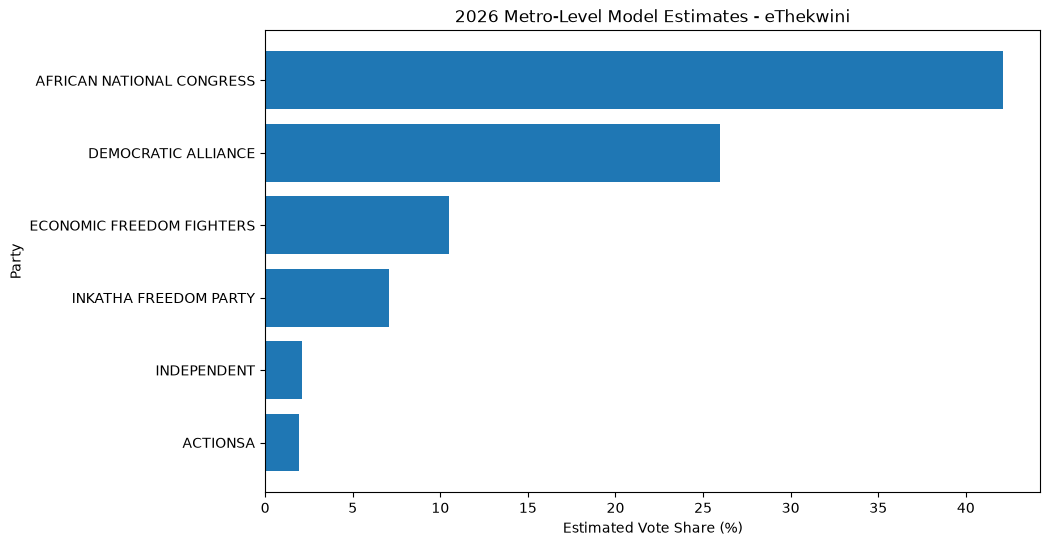

In [98]:
plt.figure(figsize=(10, 6))

plt.barh(
    forecast_plot["party"],
    forecast_plot["estimated_vote_share_2026"]
)

plt.xlabel("Estimated Vote Share (%)")
plt.ylabel("Party")
plt.title("2026 Metro-Level Model Estimates - eThekwini")

plt.gca().invert_yaxis()

plt.show()

In [99]:
largest_estimate = metro_forecast.iloc[0]

print("Party:", largest_estimate["party"])
print(
    "Estimated share:",
    round(largest_estimate["estimated_vote_share_2026"], 2),
    "%"
)
print(
    "Error-based range:",
    round(largest_estimate["lower_estimate"], 2),
    "% to",
    round(largest_estimate["upper_estimate"], 2),
    "%"
)

Party: AFRICAN NATIONAL CONGRESS
Estimated share: 42.14 %
Error-based range: 40.76 % to 43.51 %


In [100]:
metro_forecast["above_50_percent"] = (
    metro_forecast["estimated_vote_share_2026"] > 50
)

metro_forecast[
    [
        "party",
        "estimated_vote_share_2026",
        "above_50_percent"
    ]
].head(15)

,party,estimated_vote_share_2026,above_50_percent
22,AFRICAN NATIONAL CONGRESS,42.137261,False
43,DEMOCRATIC ALLIANCE,25.949556,False
49,ECONOMIC FREEDOM FIGHTERS,10.475376,False
62,INKATHA FREEDOM PARTY,7.057677,False
56,INDEPENDENT,2.127163,False
3,ACTIONSA,1.925777,False
4,ACTIVE CITIZENS COALITION,0.919812,False
12,AFRICAN CHRISTIAN DEMOCRATIC PARTY,0.768337,False
0,ABANTU BATHO CONGRESS,0.700564,False
17,AFRICAN INDEPENDENT CONGRESS,0.666322,False


In [101]:
comparison["baseline_error"] = (
    comparison["vote_share"] -
    comparison["baseline_prediction"]
)

comparison["absolute_error"] = (
    comparison["baseline_error"].abs()
)

comparison[
    [
        "party",
        "vote_share",
        "baseline_prediction",
        "baseline_error",
        "absolute_error"
    ]
].sort_values(
    "absolute_error",
    ascending=False
).head(10)

,party,vote_share,baseline_prediction,baseline_error,absolute_error
22,AFRICAN NATIONAL CONGRESS,42.137261,56.007782,-13.870521,13.870521
49,ECONOMIC FREEDOM FIGHTERS,10.475376,3.443513,7.031863,7.031863
73,NATIONAL FREEDOM PARTY,0.340158,4.700350,-4.360192,4.360192
62,INKATHA FREEDOM PARTY,7.057677,4.197241,2.860436,2.860436
56,INDEPENDENT,2.127163,4.198050,-2.070887,2.070887
43,DEMOCRATIC ALLIANCE,25.949556,26.917310,-0.967754,0.967754
17,AFRICAN INDEPENDENT CONGRESS,0.666322,1.367943,-0.701620,0.701620
12,AFRICAN CHRISTIAN DEMOCRATIC PARTY,0.768337,0.543807,0.224530,0.224530
88,TRULY ALLIANCE,0.238143,0.410585,-0.172442,0.172442
103,VRYHEIDSFRONT PLUS,0.256327,0.101141,0.155186,0.155186


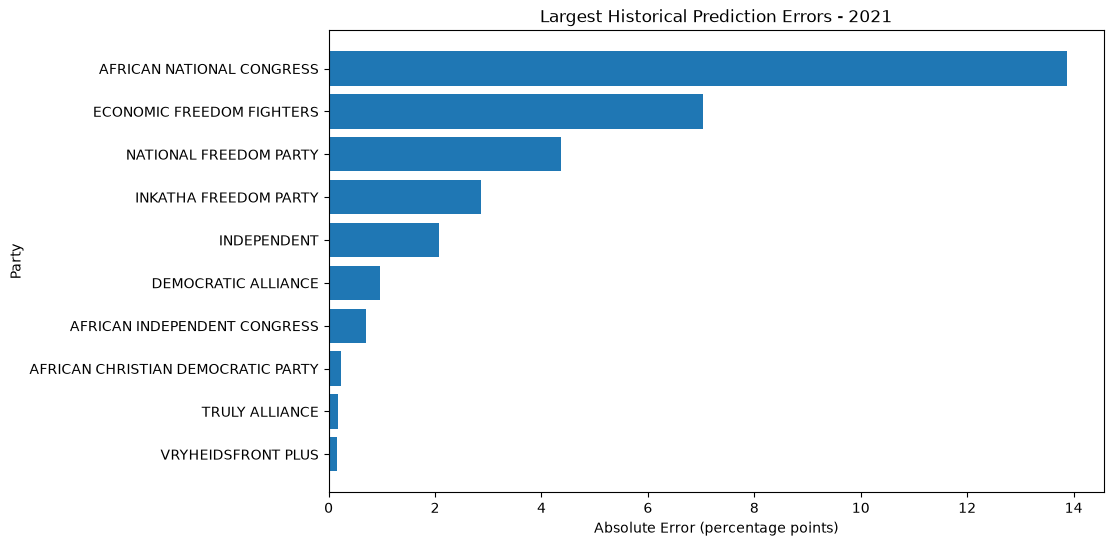

In [102]:
error_plot = comparison.sort_values(
    "absolute_error",
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    error_plot["party"],
    error_plot["absolute_error"]
)

plt.xlabel("Absolute Error (percentage points)")
plt.ylabel("Party")
plt.title("Largest Historical Prediction Errors - 2021")

plt.gca().invert_yaxis()

plt.show()

## 18. Voter Turnout Analysis

Separate IEC voter-turnout reports are used to analyse historical
participation in eThekwini.

The reports contain ward-level information for:

- registered voters;
- MEC7 votes;
- voter turnout; and
- percentage voter turnout.

The turnout analysis is kept separate from the party vote-share model
because turnout is a different prediction target.

turnout_2011_raw = pd.read_csv(
    "ETH(Voter Turnout All Wards).csv",
    header=None
)

turnout_2016_raw = pd.read_csv(
    "ETH(Voter Turnout All Wards) (1).csv",
    header=None
)

turnout_2021_raw = pd.read_csv(
    "ETH(Voter Turnout All Wards) (2).csv",
    header=None
)

In [103]:
turnout_2011_raw = pd.read_csv(
    "ETH(Voter Turnout All Wards).csv",
    header=None
)

turnout_2016_raw = pd.read_csv(
    "ETH(Voter Turnout All Wards) (1).csv",
    header=None
)

turnout_2021_raw = pd.read_csv(
    "ETH(Voter Turnout All Wards) (2).csv",
    header=None
)

In [104]:
print(turnout_2011_raw.shape)
print(turnout_2016_raw.shape)
print(turnout_2021_raw.shape)

(123, 16)
(132, 15)
(136, 19)


In [105]:
def clean_turnout(df, year):
    cleaned = df.copy()

    ward_rows = cleaned[
        cleaned[1]
        .astype(str)
        .str.match(r"^595\d+$", na=False)
    ].copy()

    result = pd.DataFrame({
        "ward": ward_rows[1],
        "registered_voters": ward_rows[6],
        "mec7_votes": ward_rows[8],
        "voter_turnout": ward_rows[9],
        "turnout_rate": ward_rows[12]
    })

    result["year"] = year

    return result.reset_index(drop=True)

In [106]:
turnout_2011 = clean_turnout(turnout_2011_raw, 2011)
turnout_2016 = clean_turnout(turnout_2016_raw, 2016)
turnout_2021 = clean_turnout(turnout_2021_raw, 2021)

In [107]:
turnout_2011.head()

,ward,registered_voters,mec7_votes,voter_turnout,turnout_rate,year
0,59500001,"15,364",1,"8,861",57.67%,2011
1,59500002,"14,295",5,"9,870",69.02%,2011
2,59500003,"18,225",1,"12,567",68.95%,2011
3,59500004,"16,370",50,"11,174",68.05%,2011
4,59500005,"14,650",82,"10,480",71.14%,2011


In [108]:
turnout_2011 = pd.DataFrame({
    "ward": turnout_2011_raw[1],
    "registered_voters": turnout_2011_raw[6],
    "mec7_votes": turnout_2011_raw[8],
    "voter_turnout": turnout_2011_raw[9],
    "turnout_rate": turnout_2011_raw[12]
})

turnout_2011 = turnout_2011[
    turnout_2011["ward"]
    .astype(str)
    .str.match(r"^595\d+$", na=False)
].copy()

turnout_2011["year"] = 2011

In [109]:
turnout_2016 = pd.DataFrame({
    "ward": turnout_2016_raw[1],
    "registered_voters": turnout_2016_raw[6],
    "mec7_votes": turnout_2016_raw[8],
    "voter_turnout": turnout_2016_raw[9],
    "turnout_rate": turnout_2016_raw[12]
})

turnout_2016 = turnout_2016[
    turnout_2016["ward"]
    .astype(str)
    .str.match(r"^595\d+$", na=False)
].copy()

turnout_2016["year"] = 2016

In [110]:
turnout_2021 = pd.DataFrame({
    "ward": turnout_2021_raw[1],
    "registered_voters": turnout_2021_raw[10],
    "mec7_votes": turnout_2021_raw[12],
    "voter_turnout": turnout_2021_raw[13],
    "turnout_rate": turnout_2021_raw[16]
})

turnout_2021 = turnout_2021[
    turnout_2021["ward"]
    .astype(str)
    .str.match(r"^595\d+$", na=False)
].copy()

turnout_2021["year"] = 2021

In [111]:
turnout_sets = [
    turnout_2011,
    turnout_2016,
    turnout_2021
]

for df in turnout_sets:

    for col in [
        "registered_voters",
        "mec7_votes",
        "voter_turnout"
    ]:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(",", "", regex=False)
            .str.replace(" ", "", regex=False)
        )

        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

    df["turnout_rate"] = (
        df["turnout_rate"]
        .astype(str)
        .str.replace("%", "", regex=False)
        .str.replace(",", ".", regex=False)
    )

    df["turnout_rate"] = pd.to_numeric(
        df["turnout_rate"],
        errors="coerce"
    )

In [112]:
turnout_2011.head()

,ward,registered_voters,mec7_votes,voter_turnout,turnout_rate,year
19,59500001,15364,1,8861,57.67,2011
20,59500002,14295,5,9870,69.02,2011
21,59500003,18225,1,12567,68.95,2011
22,59500004,16370,50,11174,68.05,2011
23,59500005,14650,82,10480,71.14,2011


In [113]:
turnout_2016.head()

,ward,registered_voters,mec7_votes,voter_turnout,turnout_rate,year
20,59500001,17187,72,13050,75.61,2016
21,59500002,15903,7,10324,64.89,2016
22,59500003,15544,1,9910,63.75,2016
23,59500004,19368,52,13103,67.47,2016
24,59500005,15202,45,10161,66.64,2016


In [114]:
turnout_2021.head()

,ward,registered_voters,mec7_votes,voter_turnout,turnout_rate,year
23,59500001,18289,160,10633,57.63,2021
24,59500002,18664,225,9263,49.04,2021
25,59500003,15086,0,6739,44.67,2021
26,59500004,19776,70,8836,44.52,2021
27,59500005,14605,20,6646,45.44,2021


In [115]:
print("2011")
print(turnout_2011.isnull().sum())

print("\n2016")
print(turnout_2016.isnull().sum())

print("\n2021")
print(turnout_2021.isnull().sum())

2011
ward                 0
registered_voters    0
mec7_votes           0
voter_turnout        0
turnout_rate         0
year                 0
dtype: int64

2016
ward                 0
registered_voters    0
mec7_votes           0
voter_turnout        0
turnout_rate         0
year                 0
dtype: int64

2021
ward                 0
registered_voters    0
mec7_votes           0
voter_turnout        0
turnout_rate         0
year                 0
dtype: int64


In [116]:
turnout = pd.concat(
    [
        turnout_2011,
        turnout_2016,
        turnout_2021
    ],
    ignore_index=True
)

turnout.head()

,ward,registered_voters,mec7_votes,voter_turnout,turnout_rate,year
0,59500001,15364,1,8861,57.67,2011
1,59500002,14295,5,9870,69.02,2011
2,59500003,18225,1,12567,68.95,2011
3,59500004,16370,50,11174,68.05,2011
4,59500005,14650,82,10480,71.14,2011


In [117]:
print("Combined turnout shape:", turnout.shape)

Combined turnout shape: (324, 6)


In [118]:
metro_turnout = (
    turnout.groupby("year")
    .agg(
        registered_voters=("registered_voters", "sum"),
        mec7_votes=("mec7_votes", "sum"),
        voters_cast=("voter_turnout", "sum")
    )
    .reset_index()
)

metro_turnout

,year,registered_voters,mec7_votes,voters_cast
0,2011,1666549,3495,990263
1,2016,1919724,5254,1148559
2,2021,1909125,8830,803791


In [119]:
metro_turnout["turnout_rate"] = (
    metro_turnout["voters_cast"] /
    (
        metro_turnout["registered_voters"] +
        metro_turnout["mec7_votes"]
    )
) * 100

metro_turnout

,year,registered_voters,mec7_votes,voters_cast,turnout_rate
0,2011,1666549,3495,990263,59.295623
1,2016,1919724,5254,1148559,59.666084
2,2021,1909125,8830,803791,41.908752


In [120]:
metro_turnout.round(2)

,year,registered_voters,mec7_votes,voters_cast,turnout_rate
0,2011,1666549,3495,990263,59.30
1,2016,1919724,5254,1148559,59.67
2,2021,1909125,8830,803791,41.91


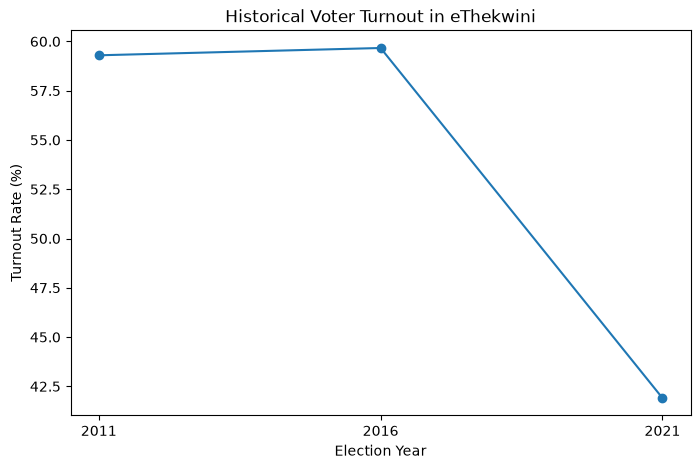

In [121]:
plt.figure(figsize=(8, 5))

plt.plot(
    metro_turnout["year"],
    metro_turnout["turnout_rate"],
    marker="o"
)

plt.title("Historical Voter Turnout in eThekwini")
plt.xlabel("Election Year")
plt.ylabel("Turnout Rate (%)")

plt.xticks([2011, 2016, 2021])

plt.show()

In [122]:
turnout_train = metro_turnout[
    metro_turnout["year"] < 2021
]

turnout_test = metro_turnout[
    metro_turnout["year"] == 2021
]

In [123]:
turnout_model_test = LinearRegression()

turnout_model_test.fit(
    turnout_train[["year"]],
    turnout_train["turnout_rate"]
)

turnout_2021_prediction = turnout_model_test.predict(
    turnout_test[["year"]]
)

turnout_test_mae = mean_absolute_error(
    turnout_test["turnout_rate"],
    turnout_2021_prediction
)

print("Actual 2021 turnout:",
      round(turnout_test["turnout_rate"].iloc[0], 2))

print("Predicted 2021 turnout:",
      round(turnout_2021_prediction[0], 2))

print("Historical test error:",
      round(turnout_test_mae, 2),
      "percentage points")

Actual 2021 turnout: 41.91
Predicted 2021 turnout: 60.04
Historical test error: 18.13 percentage points


In [124]:
final_turnout_model = LinearRegression()

final_turnout_model.fit(
    metro_turnout[["year"]],
    metro_turnout["turnout_rate"]
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[-1.74]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['year']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3559
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [125]:
turnout_2026_rate = final_turnout_model.predict(
    pd.DataFrame({"year": [2026]})
)[0]

print(
    "2026 estimated turnout rate:",
    round(turnout_2026_rate, 2),
    "%"
)

2026 estimated turnout rate: 36.24 %


In [126]:
registered_model = LinearRegression()

registered_model.fit(
    metro_turnout[["year"]],
    metro_turnout["registered_voters"]
)

estimated_registered_2026 = registered_model.predict(
    pd.DataFrame({"year": [2026]})
)[0]

print(
    "Estimated registered voters for 2026:",
    round(estimated_registered_2026)
)

Estimated registered voters for 2026: 2074375


In [127]:
estimated_voters_2026 = (
    estimated_registered_2026 *
    turnout_2026_rate / 100
)

print(
    "Estimated voters in 2026:",
    round(estimated_voters_2026)
)

Estimated voters in 2026: 751683


In [128]:
turnout_summary = pd.DataFrame({
    "Measure": [
        "Estimated registered voters",
        "Estimated turnout rate (%)",
        "Estimated voters"
    ],
    "2026 Estimate": [
        round(estimated_registered_2026),
        round(turnout_2026_rate, 2),
        round(estimated_voters_2026)
    ]
})

turnout_summary

,Measure,2026 Estimate
0,Estimated registered voters,2074375.00
1,Estimated turnout rate (%),36.24
2,Estimated voters,751683.00


In [129]:
metro_forecast.to_csv(
    "ethekwini_2026_metro_forecast.csv",
    index=False
)

In [130]:
turnout_summary.to_csv(
    "ethekwini_2026_turnout_estimate.csv",
    index=False
)

In [131]:
def clean_ward_file(filename, year, ward_id):
    df = pd.read_csv(filename, header=None)

    # Find the first row containing Party Name
    header_row = df[
        df.apply(
            lambda row: row.astype(str)
            .str.contains("Party Name", case=False, na=False)
            .any(),
            axis=1
        )
    ].index[0]

    # Data begins after the two header rows
    data = df.iloc[header_row + 2:].copy()

    # Keep rows where a party name exists
    data = data[data[1].notna()].copy()

    # Keep useful columns
    result = data[[1, 4, 5, 8, 9, 11, 12]].copy()

    result.columns = [
        "party",
        "ward_votes",
        "ward_share",
        "pr_votes",
        "pr_share",
        "total_votes",
        "vote_share"
    ]

    result["year"] = year
    result["ward"] = str(ward_id)

    return result.reset_index(drop=True)

In [132]:
ward25_2011 = clean_ward_file(
    "59500025(Results Summary).csv", 2011, 59500025
)

ward60_2011 = clean_ward_file(
    "59500060(Results Summary).csv", 2011, 59500060
)

ward73_2011 = clean_ward_file(
    "59500073(Results Summary).csv", 2011, 59500073
)

ward25_2016 = clean_ward_file(
    "59500025(Results Summary - Independent).csv", 2016, 59500025
)

ward60_2016 = clean_ward_file(
    "59500060(Results Summary - Independent).csv", 2016, 59500060
)

ward73_2016 = clean_ward_file(
    "59500073(Results Summary - Independent).csv", 2016, 59500073
)

ward25_2021 = clean_ward_file(
    "59500025(Results Summary - Independent) (1).csv", 2021, 59500025
)

ward60_2021 = clean_ward_file(
    "59500060(Results Summary - Independent) (1).csv", 2021, 59500060
)

ward73_2021 = clean_ward_file(
    "59500073(Results Summary - Independent) (1).csv", 2021, 59500073
)

In [133]:
ward_results = pd.concat(
    [
        ward25_2011, ward60_2011, ward73_2011,
        ward25_2016, ward60_2016, ward73_2016,
        ward25_2021, ward60_2021, ward73_2021
    ],
    ignore_index=True
)

In [134]:
ward_results["party"] = (
    ward_results["party"]
    .astype(str)
    .str.strip()
    .str.upper()
    .str.replace(r"\s+", " ", regex=True)
)

In [135]:
vote_cols = [
    "ward_votes",
    "pr_votes",
    "total_votes"
]

for col in vote_cols:
    ward_results[col] = (
        ward_results[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.replace(" ", "", regex=False)
        .replace("-", np.nan)
    )

    ward_results[col] = pd.to_numeric(
        ward_results[col],
        errors="coerce"
    )

In [136]:
share_cols = [
    "ward_share",
    "pr_share",
    "vote_share"
]

for col in share_cols:
    ward_results[col] = (
        ward_results[col]
        .astype(str)
        .str.replace("%", "", regex=False)
        .str.replace(",", ".", regex=False)
        .str.strip()
        .replace("-", np.nan)
    )

    ward_results[col] = pd.to_numeric(
        ward_results[col],
        errors="coerce"
    )

In [137]:
ward_results[
    ["ward", "year", "party", "total_votes", "vote_share"]
].head(30)

,ward,year,party,total_votes,vote_share
0,59500025,2011,AFRICAN CHRISTIAN ALLIANCE-AFRIKANER CHRISTEN ...,NaN,28.000
1,59500025,2011,AFRICAN CHRISTIAN DEMOCRATIC PARTY,NaN,172.000
2,59500025,2011,AFRICAN NATIONAL CONGRESS,NaN,7.174
3,59500025,2011,AFRICAN PEOPLE'S CONVENTION,NaN,55.000
4,59500025,2011,AZANIAN PEOPLE'S ORGANISATION,NaN,12.000
5,59500025,2011,BLACK CONSCIOUSNESS PARTY,NaN,7.000
6,59500025,2011,CONGRESS OF THE PEOPLE,NaN,159.000
7,59500025,2011,DEMOCRATIC ALLIANCE/DEMOKRATIESE ALLIANSIE,NaN,5.855
8,59500025,2011,INKATHA FREEDOM PARTY,NaN,288.000
9,59500025,2011,MINORITY FRONT,NaN,1.118


In [138]:
ward_results[
    ["ward", "year", "party", "total_votes", "vote_share"]
].isnull().sum()

ward            0
year            0
party           0
total_votes    63
vote_share     18
dtype: int64

In [139]:
ward_check = (
    ward_results.groupby(["ward", "year"])
    .agg(
        number_of_parties=("party", "count"),
        total_votes=("total_votes", "sum")
    )
    .reset_index()
)

ward_check

,ward,year,number_of_parties,total_votes
0,59500025,2011,21,0.0
1,59500025,2016,31,78111.0
2,59500025,2021,55,45311.0
3,59500060,2011,21,0.0
4,59500060,2016,31,71091.0
5,59500060,2021,54,55315.0
6,59500073,2011,21,0.0
7,59500073,2016,31,76186.0
8,59500073,2021,54,56964.0


In [140]:
ward_check.pivot(
    index="ward",
    columns="year",
    values="total_votes"
)

year,2011,2016,2021
ward,,,
59500025,0.0,78111.0,45311.0
59500060,0.0,71091.0,55315.0
59500073,0.0,76186.0,56964.0


In [141]:
party_presence = (
    ward_results.groupby(["ward", "party"])["year"]
    .nunique()
    .reset_index(name="election_count")
)

party_presence.sort_values(
    ["ward", "election_count"],
    ascending=[True, False]
).head(30)

,ward,party,election_count
9,59500025,AFRICAN CHRISTIAN DEMOCRATIC PARTY,3
15,59500025,AFRICAN NATIONAL CONGRESS,3
17,59500025,AFRICAN PEOPLE'S CONVENTION,3
22,59500025,AZANIAN PEOPLE'S ORGANISATION,3
25,59500025,CONGRESS OF THE PEOPLE,3
37,59500025,INKATHA FREEDOM PARTY,3
42,59500025,MINORITY FRONT,3
54,59500025,TOTAL SPOILT VOTES,3
55,59500025,TOTAL VALID VOTES,3
56,59500025,TOTAL VOTER TURNOUT,3


In [142]:
# Fix missing total votes
ward_results["total_votes"] = (
    ward_results["ward_votes"].fillna(0) +
    ward_results["pr_votes"].fillna(0)
)

# Recalculate vote share inside each ward and year
ward_results["vote_share"] = (
    ward_results["total_votes"] /
    ward_results.groupby(["ward", "year"])["total_votes"].transform("sum")
) * 100

In [143]:
ward_results[
    ["ward", "year", "party", "total_votes", "vote_share"]
].head(20)

,ward,year,party,total_votes,vote_share
0,59500025,2011,AFRICAN CHRISTIAN ALLIANCE-AFRIKANER CHRISTEN ...,28.0,0.057870
1,59500025,2011,AFRICAN CHRISTIAN DEMOCRATIC PARTY,172.0,0.355489
2,59500025,2011,AFRICAN NATIONAL CONGRESS,7174.0,14.827216
3,59500025,2011,AFRICAN PEOPLE'S CONVENTION,55.0,0.113674
4,59500025,2011,AZANIAN PEOPLE'S ORGANISATION,12.0,0.024802
5,59500025,2011,BLACK CONSCIOUSNESS PARTY,7.0,0.014468
6,59500025,2011,CONGRESS OF THE PEOPLE,159.0,0.328621
7,59500025,2011,DEMOCRATIC ALLIANCE/DEMOKRATIESE ALLIANSIE,5855.0,12.101108
8,59500025,2011,INKATHA FREEDOM PARTY,288.0,0.595238
9,59500025,2011,MINORITY FRONT,1118.0,2.310681


In [144]:
ward_results = ward_results.sort_values(
    ["ward", "party", "year"]
)

ward_results["previous_vote_share"] = (
    ward_results
    .groupby(["ward", "party"])["vote_share"]
    .shift(1)
)

In [145]:
ward_test = ward_results[
    (ward_results["year"] == 2021) &
    (ward_results["previous_vote_share"].notna())
].copy()

In [146]:
ward_test["prediction"] = ward_test["previous_vote_share"]

ward_mae = mean_absolute_error(
    ward_test["vote_share"],
    ward_test["prediction"]
)

print("Ward baseline MAE:", round(ward_mae, 2))

Ward baseline MAE: 0.34


In [147]:
ward_forecast = ward_results[
    ward_results["year"] == 2021
][
    ["ward", "party", "vote_share"]
].copy()

ward_forecast["estimated_share_2026"] = (
    ward_forecast["vote_share"]
)

ward_forecast["lower_estimate"] = (
    ward_forecast["estimated_share_2026"] - ward_mae
).clip(lower=0)

ward_forecast["upper_estimate"] = (
    ward_forecast["estimated_share_2026"] + ward_mae
).clip(upper=100)

In [148]:
ward_leaders = (
    ward_forecast
    .sort_values(
        ["ward", "estimated_share_2026"],
        ascending=[True, False]
    )
    .groupby("ward")
    .head(1)
)

ward_leaders

,ward,party,vote_share,estimated_share_2026,lower_estimate,upper_estimate
209,59500025,TOTAL VOTES CAST,33.638059,33.638059,33.298341,33.977777
263,59500060,TOTAL VOTES CAST,33.677869,33.677869,33.338151,34.017588
317,59500073,TOTAL VOTES CAST,33.497497,33.497497,33.157778,33.837215


In [149]:
ward_forecast.to_csv(
    "ethekwini_2026_ward_forecast.csv",
    index=False
)

ward_leaders.to_csv(
    "ethekwini_2026_ward_leaders.csv",
    index=False
)

In [150]:
print("=== METRO OUTPUT ===")
display(metro_forecast.head(10))

print("\n=== THREE WARDS ===")
display(ward_leaders)

print("\n=== TURNOUT ===")
display(turnout_summary)

=== METRO OUTPUT ===


,party,estimated_vote_share_2026,lower_estimate,upper_estimate,above_50_percent
22,AFRICAN NATIONAL CONGRESS,42.137261,40.763733,43.510790,False
43,DEMOCRATIC ALLIANCE,25.949556,24.576028,27.323084,False
49,ECONOMIC FREEDOM FIGHTERS,10.475376,9.101848,11.848905,False
62,INKATHA FREEDOM PARTY,7.057677,5.684149,8.431206,False
56,INDEPENDENT,2.127163,0.753635,3.500691,False
3,ACTIONSA,1.925777,0.552248,3.299305,False
4,ACTIVE CITIZENS COALITION,0.919812,0.000000,2.293341,False
12,AFRICAN CHRISTIAN DEMOCRATIC PARTY,0.768337,0.000000,2.141866,False
0,ABANTU BATHO CONGRESS,0.700564,0.000000,2.074092,False
17,AFRICAN INDEPENDENT CONGRESS,0.666322,0.000000,2.039851,False



=== THREE WARDS ===


,ward,party,vote_share,estimated_share_2026,lower_estimate,upper_estimate
209,59500025,TOTAL VOTES CAST,33.638059,33.638059,33.298341,33.977777
263,59500060,TOTAL VOTES CAST,33.677869,33.677869,33.338151,34.017588
317,59500073,TOTAL VOTES CAST,33.497497,33.497497,33.157778,33.837215



=== TURNOUT ===


,Measure,2026 Estimate
0,Estimated registered voters,2074375.00
1,Estimated turnout rate (%),36.24
2,Estimated voters,751683.00


In [151]:
import os
print(os.getcwd())

C:\Users\nhlak


In [155]:
project_folder = r"C:\Users\YourName\Desktop\Election_Analytics"

metro_forecast.to_csv(
    project_folder + r"\ethekwini_2026_metro_forecast.csv",
    index=False
)

ward_forecast.to_csv(
    project_folder + r"\ethekwini_2026_ward_forecast.csv",
    index=False
)

ward_leaders.to_csv(
    project_folder + r"\ethekwini_2026_ward_leaders.csv",
    index=False
)

turnout_summary.to_csv(
    project_folder + r"\ethekwini_2026_turnout_estimate.csv",
    index=False
)

OSError: Cannot save file into a non-existent directory: 'C:\Users\YourName\Desktop\Election_Analytics'

In [ ]:
variables = [
    "metro_forecast",
    "ward_forecast",
    "ward_leaders",
    "turnout_summary"
]

for name in variables:
    print(name, "=", name in globals())

In [153]:
print("metro_forecast" in globals())
print("ward_forecast" in globals())
print("ward_leaders" in globals())
print("turnout_summary" in globals())

True
True
True
True


In [154]:
metro_forecast.to_csv("ethekwini_2026_metro_forecast.csv", index=False)

ward_forecast.to_csv("ethekwini_2026_ward_forecast.csv", index=False)

ward_leaders.to_csv("ethekwini_2026_ward_leaders.csv", index=False)

turnout_summary.to_csv("ethekwini_2026_turnout_estimate.csv", index=False)

In [159]:
import os
print(os.getcwd())

C:\Users\nhlak


In [160]:
project_folder = r"C:\Users\nhlak\OneDrive\Desktop\Elections Analytics"

metro_forecast.to_csv(
    project_folder + r"\ethekwini_2026_metro_forecast.csv",
    index=False
)

ward_forecast.to_csv(
    project_folder + r"\ethekwini_2026_ward_forecast.csv",
    index=False
)

ward_leaders.to_csv(
    project_folder + r"\ethekwini_2026_ward_leaders.csv",
    index=False
)

turnout_summary.to_csv(
    project_folder + r"\ethekwini_2026_turnout_estimate.csv",
    index=False
)

print("Saved successfully")

Saved successfully


In [161]:
import os
print(os.listdir(project_folder))

['app.py', 'ethekwini_2026_metro_forecast.csv', 'ethekwini_2026_turnout_estimate.csv', 'ethekwini_2026_ward_forecast.csv', 'ethekwini_2026_ward_leaders.csv', 'requirements.txt']


In [162]:
import joblib

In [163]:
joblib.dump(linear_model, "linear_vote_model.joblib")
joblib.dump(rf_model, "random_forest_vote_model.joblib")
joblib.dump(final_turnout_model, "turnout_model.joblib")

['turnout_model.joblib']

In [164]:
project_folder = r"C:\Users\nhlak\OneDrive\Desktop\Elections Analytics"

joblib.dump(
    linear_model,
    project_folder + r"\linear_vote_model.joblib"
)

joblib.dump(
    rf_model,
    project_folder + r"\random_forest_vote_model.joblib"
)

joblib.dump(
    final_turnout_model,
    project_folder + r"\turnout_model.joblib"
)

['C:\\Users\\nhlak\\OneDrive\\Desktop\\Elections Analytics\\turnout_model.joblib']